In [1]:
import pandas as pd
import numpy as np

In [30]:
df = pd.read_csv("../01-Intro/car_fuel_efficiency_2026.csv")

## Preparing the dataset

In [31]:
df = df[["engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]]

## EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

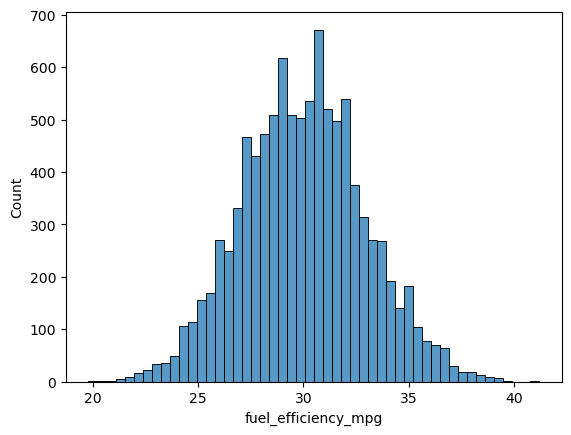

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df.fuel_efficiency_mpg, bins=50)

## 1. Missing values

In [5]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## 2. Median for horsepower

In [6]:
df.horsepower.median()

np.float64(254.0)

## 3. Filling NAs

In [10]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [24]:
import pandas as pd
import numpy as np

cols = ['engine_displacement', 'horsepower', 'vehicle_weight',
        'model_year', 'fuel_efficiency_mpg']
df = df[cols]

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))

def prepare_X(df, fill_value):
    df_num = df[features].copy()
    df_num['horsepower'] = df_num['horsepower'].fillna(fill_value)
    return df_num.values

# Filling with 0
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
print('Filled with 0:   ', round(rmse(y_val, y_pred), 3))

# Filling with mean
mean_hp = df_train['horsepower'].mean()
X_train = prepare_X(df_train, mean_hp)
X_val = prepare_X(df_val, mean_hp)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)
print('Filled with mean:', round(rmse(y_val, y_pred), 3))

Filled with 0:    2.205
Filled with mean: 2.202


## 4. Best regularization

In [32]:
def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

r_list = [0, 0.01, 0.1, 1, 5, 10, 100]
for i in r_list:
    w0, w = train_linear_regression(X_train, y_train, r=i)
    y_pred = w0 + X_val.dot(w)
    print(f'RMSE with r = {i}: ', round(rmse(y_val, y_pred), 4))

RMSE with r = 0:  2.2053
RMSE with r = 0.01:  2.2058
RMSE with r = 0.1:  2.2241
RMSE with r = 1:  2.3492
RMSE with r = 5:  2.4094
RMSE with r = 10:  2.4195
RMSE with r = 100:  2.4292


## 5. RMSE standard deviation

In [59]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
values = []
for i in seeds:
    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    X_train = prepare_X(df_train, 0)
    X_val = prepare_X(df_val, 0)

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    values.append(rmse(y_val, y_pred))
    print(f'RMSE with seed = {i}: ', round(rmse(y_val, y_pred), 4))
print("")
round(np.std(values), 3)

RMSE with seed = 0:  2.2392
RMSE with seed = 1:  2.2021
RMSE with seed = 2:  2.1634
RMSE with seed = 3:  2.2044
RMSE with seed = 4:  2.2019
RMSE with seed = 5:  2.2458
RMSE with seed = 6:  2.2697
RMSE with seed = 7:  2.1908
RMSE with seed = 8:  2.2166
RMSE with seed = 9:  2.207



np.float64(0.029)

## 6. Evaluation on test

In [65]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

df_full_train = pd.concat([df_train, df_val])

X_full_train = prepare_X(df_full_train, 0)
y_full_train = df_full_train['fuel_efficiency_mpg'].values

X_test = prepare_X(df_test, 0)
y_test = df_test['fuel_efficiency_mpg'].values

def train_linear_regression(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]
    
w0, w = train_linear_regression(X_full_train, y_full_train, r=0.001)
y_pred = w0 + X_test.dot(w)
print(round(rmse(y_test, y_pred), 3))

2.236
